<a href="https://colab.research.google.com/github/Ladyjinxxx/codveda-machine-learning-internship/blob/main/Level3_Task3_NeuralNetwork_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Level 3 - Task 3: Neural Networks with TensorFlow/Keras
### Codveda Technologies Machine Learning Internship

**Dataset:** MNIST Handwritten Digits

In [1]:
# Cell 1: Mount Google Drive
# Connects this notebook to Google Drive so the plots and trained model can be saved.
# The MNIST dataset itself doesn't need Drive since it's built directly into TensorFlow.

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Set the main project folder and organize outputs into clear subfolders
project_path = '/content/drive/MyDrive/Codveda_Internship/Level3_Task3_NeuralNetwork_MNIST'
base_path = Path(project_path)

output_path = base_path / 'outputs'
charts_path = output_path / 'charts'
tables_path = output_path / 'tables'
model_path = output_path / 'model'

for folder in [charts_path, tables_path, model_path]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders ready.")
print(f"Charts will be saved to: {charts_path}")
print(f"Model will be saved to: {model_path}")

Mounted at /content/drive
Project folders ready.
Charts will be saved to: /content/drive/MyDrive/Codveda_Internship/Level3_Task3_NeuralNetwork_MNIST/outputs/charts
Model will be saved to: /content/drive/MyDrive/Codveda_Internship/Level3_Task3_NeuralNetwork_MNIST/outputs/model


In [2]:
# Cell 2: Install Libraries
# Colab already comes with TensorFlow, numpy, matplotlib, seaborn, and scikit-learn pre-installed.
# No additional installation is needed, so this cell just upgrades TensorFlow to be safe.

!pip install -q --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 23.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.21.0 which is i

In [3]:
# Cell 3: Import Libraries
# Only the libraries actually used in this notebook are imported.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
sns.set_style('whitegrid')

# Make results reproducible across runs
keras.utils.set_random_seed(42)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Number of classes: 10


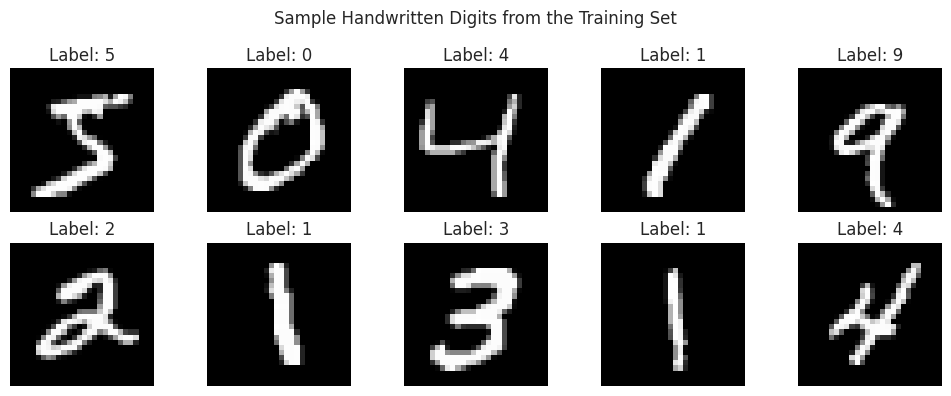


Each image is a 28x28 grid of pixel values ranging from 0 (black) to 255 (white),
and each label tells us which digit (0-9) the image represents.


In [4]:
# Cell 4: Load the MNIST Dataset
# MNIST contains 70,000 grayscale images of handwritten digits (0-9), each 28x28 pixels.
# It comes pre-split into a training set and a test set, which is standard practice so
# the model can later be evaluated on images it has never seen during training.

(X_train, y_train), (X_test, y_test) = mnist.load_data()

num_classes = len(np.unique(y_train))

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Number of classes: {num_classes}")

# Display a few sample digits with their labels
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle('Sample Handwritten Digits from the Training Set')
plt.tight_layout()
plt.savefig(charts_path / 'sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEach image is a 28x28 grid of pixel values ranging from 0 (black) to 255 (white),")
print("and each label tells us which digit (0-9) the image represents.")

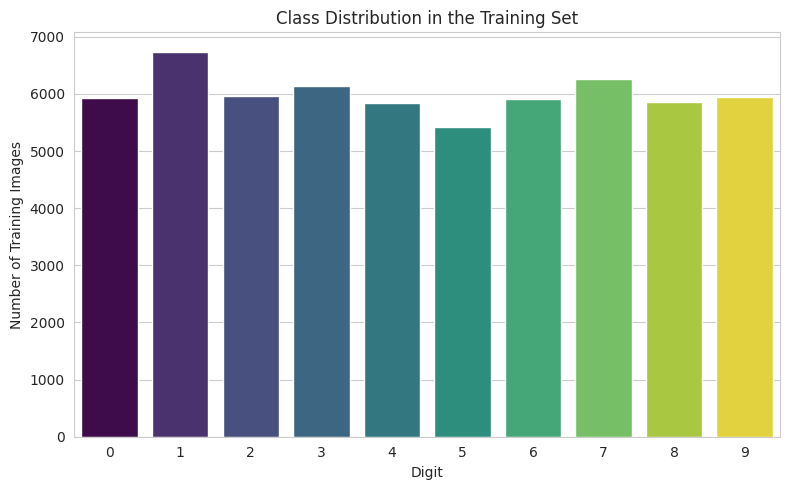

Number of training images per digit:
  Digit 0: 5923 images
  Digit 1: 6742 images
  Digit 2: 5958 images
  Digit 3: 6131 images
  Digit 4: 5842 images
  Digit 5: 5421 images
  Digit 6: 5918 images
  Digit 7: 6265 images
  Digit 8: 5851 images
  Digit 9: 5949 images

Smallest class has 5421 images, largest has 6742 images.
The counts are close to each other, so the dataset is reasonably balanced
and the model won't be biased toward predicting any single digit more often.


In [5]:
# Cell 5: Exploratory Data Analysis
# Check how many examples of each digit exist, so we know whether the dataset is balanced.

unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 5))
sns.barplot(x=unique, y=counts, hue=unique, palette='viridis', legend=False)
plt.xlabel('Digit')
plt.ylabel('Number of Training Images')
plt.title('Class Distribution in the Training Set')
plt.tight_layout()
plt.savefig(charts_path / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Number of training images per digit:")
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} images")

print(f"\nSmallest class has {counts.min()} images, largest has {counts.max()} images.")
print("The counts are close to each other, so the dataset is reasonably balanced")
print("and the model won't be biased toward predicting any single digit more often.")

In [6]:
# Cell 6: Data Preprocessing
# Prepare the images and labels so they can be fed into the neural network.

# Pixel values range from 0 to 255. Scaling them to a 0-1 range (normalization)
# helps the network train faster and more stably, since large input values can
# cause unstable gradient updates during backpropagation.
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# A Dense (fully-connected) network expects a 1D vector per sample, not a 2D image,
# so each 28x28 image is flattened into a single vector of 784 pixel values.
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

# Labels are one-hot encoded (e.g. 3 becomes [0,0,0,1,0,0,0,0,0,0]) because the
# output layer will use softmax with 10 units, one probability per digit class.
y_train_encoded = to_categorical(y_train, num_classes)
y_test_encoded = to_categorical(y_test, num_classes)

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened testing data shape: {X_test_flat.shape}")
print(f"One-hot encoded label shape: {y_train_encoded.shape}")
print(f"\nExample - original label: {y_train[0]}, one-hot encoded: {y_train_encoded[0]}")

Flattened training data shape: (60000, 784)
Flattened testing data shape: (10000, 784)
One-hot encoded label shape: (60000, 10)

Example - original label: 5, one-hot encoded: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [7]:
# Cell 7: Build the Neural Network
# A simple feed-forward (fully-connected) network is enough to classify MNIST digits well.

model = keras.Sequential([
    # Input layer: receives the 784 flattened pixel values per image
    layers.Input(shape=(784,)),

    # Hidden Layer 1: learns general patterns like edges and strokes.
    # ReLU is used because it trains fast and avoids vanishing gradients.
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),  # randomly turns off 20% of neurons during training to reduce overfitting

    # Hidden Layer 2: combines the patterns from layer 1 into more complex shapes.
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    # Output Layer: 10 units, one per digit (0-9).
    # Softmax converts the raw outputs into probabilities that sum to 1.
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Cell 8: Compile the Model
# Configure how the network will learn from its mistakes.

model.compile(
    optimizer='adam',                  # adapts the learning rate automatically, which works well in most cases
    loss='categorical_crossentropy',   # standard loss function for multi-class classification with one-hot labels
    metrics=['accuracy']               # track accuracy alongside loss during training
)

print("Model compiled with:")
print("  Optimizer: Adam")
print("  Loss function: Categorical Crossentropy")
print("  Metric: Accuracy")

Model compiled with:
  Optimizer: Adam
  Loss function: Categorical Crossentropy
  Metric: Accuracy


In [9]:
# Cell 9: Train the Model
# The model learns by repeatedly adjusting its weights through backpropagation,
# using a portion of the training data to check its progress along the way.

history = model.fit(
    X_train_flat, y_train_encoded,
    validation_split=0.1,   # holds out 10% of training data to monitor performance on unseen data each epoch
    epochs=15,
    batch_size=128,
    verbose=1
)

print("\nTraining complete.")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8599 - loss: 0.4678 - val_accuracy: 0.9572 - val_loss: 0.1514
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9375 - loss: 0.2101 - val_accuracy: 0.9700 - val_loss: 0.1104
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9527 - loss: 0.1583 - val_accuracy: 0.9745 - val_loss: 0.0916
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9616 - loss: 0.1273 - val_accuracy: 0.9762 - val_loss: 0.0834
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9665 - loss: 0.1100 - val_accuracy: 0.9768 - val_loss: 0.0769
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9707 - loss: 0.0960 - val_accuracy: 0.9768 - val_loss: 0.0740
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9726 - loss: 0.0887 - val_accuracy: 0.9780 - val_loss: 0.0697
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9748 - loss: 0.0792 - val_accuracy: 

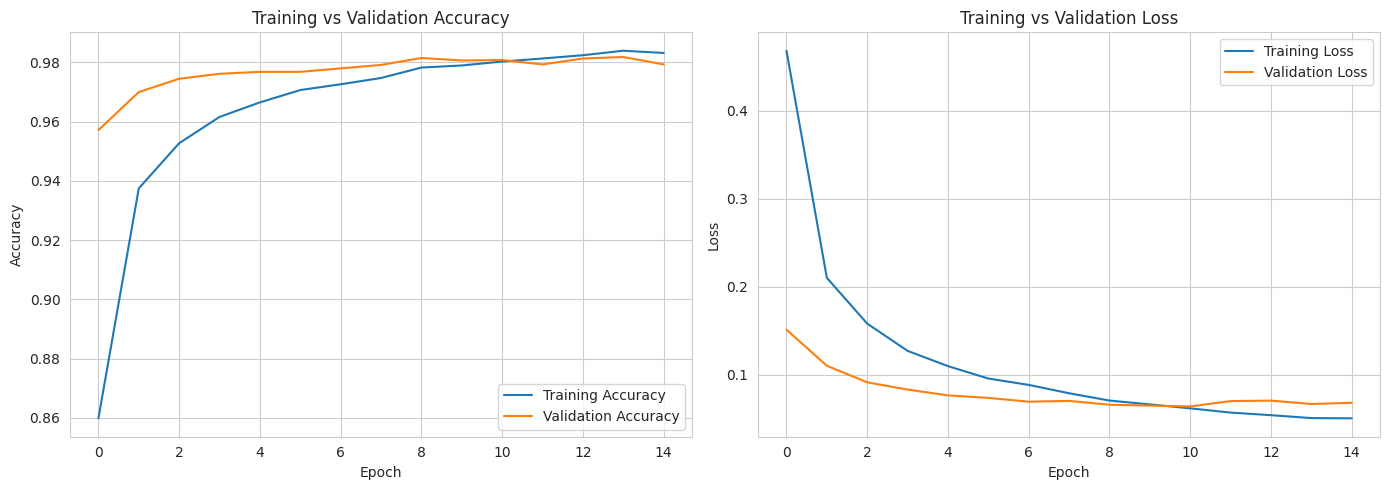

If the training and validation lines stay close together, the model is learning
general patterns well. A growing gap between them (training much better than
validation) would signal overfitting.


In [10]:
# Cell 10: Visualize Training Performance
# Plot how accuracy and loss changed over each epoch for both training and validation data.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(charts_path / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("If the training and validation lines stay close together, the model is learning")
print("general patterns well. A growing gap between them (training much better than")
print("validation) would signal overfitting.")

Test Accuracy: 0.9791
Test Loss: 0.0751


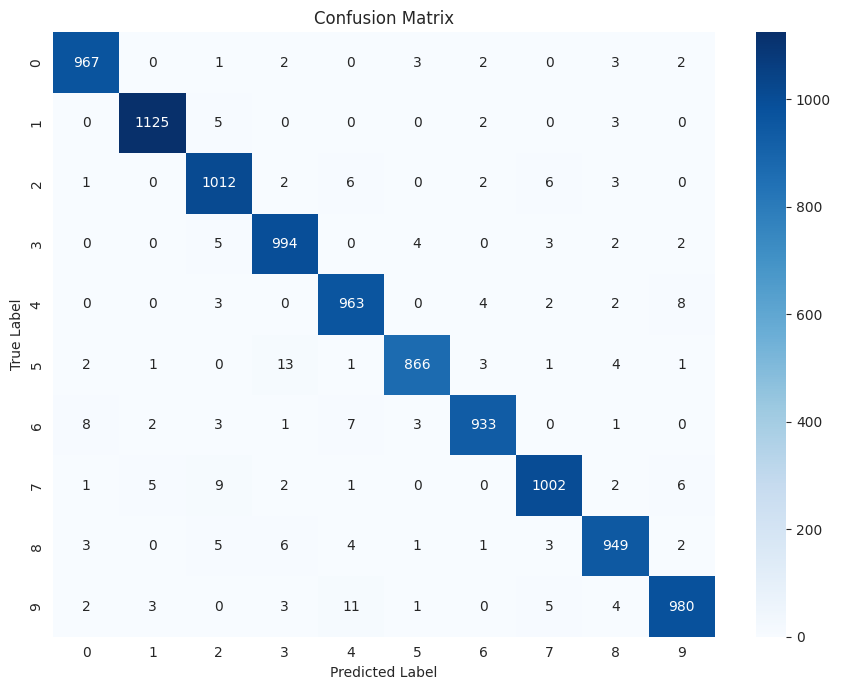


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.99      0.97      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [11]:
# Cell 11: Evaluate the Model
# Check how well the trained model performs on the test set it has never seen.

test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_encoded, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predicted classes for the confusion matrix and classification report
y_pred_probs = model.predict(X_test_flat, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# The confusion matrix shows which digits are most often confused with each other
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(charts_path / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# The classification report gives precision, recall, and F1-score per digit
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

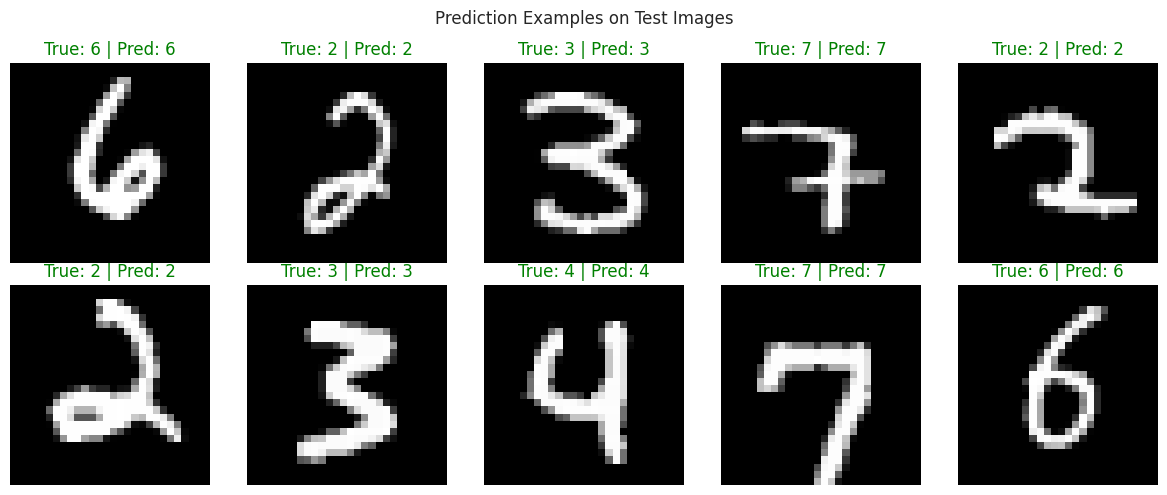

In [12]:
# Cell 12: Prediction Examples
# Show the model's predictions on individual test images alongside their true labels.

sample_indices = np.random.choice(len(X_test), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(X_test[idx], cmap='gray')
    predicted_label = y_pred[idx]
    true_label = y_test[idx]
    color = 'green' if predicted_label == true_label else 'red'
    ax.set_title(f"True: {true_label} | Pred: {predicted_label}", color=color)
    ax.axis('off')
plt.suptitle('Prediction Examples on Test Images')
plt.tight_layout()
plt.savefig(charts_path / 'prediction_examples.png', dpi=300, bbox_inches='tight')
plt.show()

Number of misclassified test images: 209 out of 10000


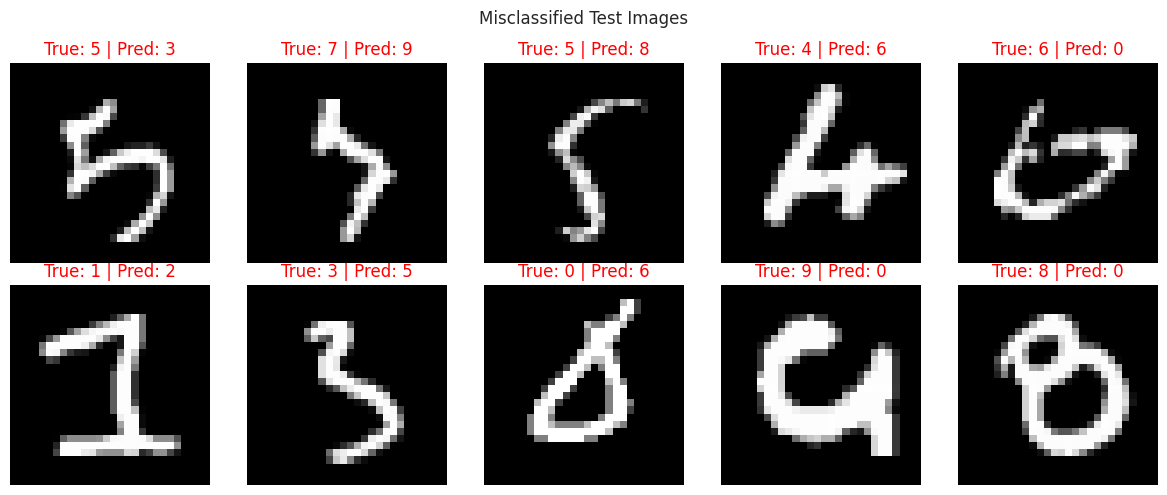


Most mistakes happen between digits that look visually similar when handwritten,
such as 4 and 9, or 3 and 5. Unusual handwriting styles, messy strokes, or digits
written unusually thin or thick also make classification harder for the network.


In [13]:
# Cell 13: Error Analysis
# Look specifically at digits the model got wrong, to understand its weaknesses.

misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Number of misclassified test images: {len(misclassified_idx)} out of {len(y_test)}")

sample_errors = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, sample_errors):
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}", color='red')
    ax.axis('off')
plt.suptitle('Misclassified Test Images')
plt.tight_layout()
plt.savefig(charts_path / 'misclassified_images.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMost mistakes happen between digits that look visually similar when handwritten,")
print("such as 4 and 9, or 3 and 5. Unusual handwriting styles, messy strokes, or digits")
print("written unusually thin or thick also make classification harder for the network.")

In [14]:
# Cell 14: Model Interpretation
# Base the discussion below on the actual numbers produced during training and evaluation.

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
acc_gap = final_train_acc - final_val_acc

print(f"Final training accuracy: {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Gap between training and validation accuracy: {acc_gap:.4f}\n")

if acc_gap > 0.05:
    fit_message = ("The training accuracy is noticeably higher than the validation accuracy, "
                    "which suggests the model is starting to overfit: it is memorizing patterns "
                    "specific to the training images rather than fully generalizing.")
elif final_train_acc < 0.9:
    fit_message = ("Both training and validation accuracy are relatively low, which suggests the "
                    "model is underfitting and could benefit from more epochs, more neurons, or a "
                    "longer training time.")
else:
    fit_message = ("Training and validation accuracy stay close to each other, which suggests the "
                    "model is generalizing well rather than simply memorizing the training images.")

print(fit_message)

print("""
Strengths of neural networks:
- Automatically learn useful patterns directly from raw pixel data, without manual feature engineering.
- Scale well to large, complex datasets like image collections.

Limitations observed here:
- A plain feed-forward network flattens each image, so it loses information about which
  pixels are next to each other spatially. A Convolutional Neural Network (CNN) would likely
  perform even better on image data for this reason.
- Performance can still degrade on unusual handwriting styles, as seen in the misclassified
  examples above.
""")

Final training accuracy: 0.9832
Final validation accuracy: 0.9793
Test accuracy: 0.9791
Gap between training and validation accuracy: 0.0039

Training and validation accuracy stay close to each other, which suggests the model is generalizing well rather than simply memorizing the training images.

Strengths of neural networks:
- Automatically learn useful patterns directly from raw pixel data, without manual feature engineering.
- Scale well to large, complex datasets like image collections.

Limitations observed here:
- A plain feed-forward network flattens each image, so it loses information about which
  pixels are next to each other spatially. A Convolutional Neural Network (CNN) would likely
  perform even better on image data for this reason.
- Performance can still degrade on unusual handwriting styles, as seen in the misclassified
  examples above.



In [15]:
# Cell 15: Final Conclusion
# Summary of what this notebook accomplished, and save the trained model for future use.

model.save(model_path / 'mnist_neural_network.keras')
print(f"Trained model saved to: {model_path / 'mnist_neural_network.keras'}")

print(f"""
CONCLUSION

A feed-forward neural network was built with TensorFlow/Keras to classify handwritten
digits from the MNIST dataset. The network used two hidden layers with ReLU activation
and Dropout to reduce overfitting, and a softmax output layer to produce a probability
for each of the 10 digit classes.

After training with backpropagation over several epochs, the model reached a test
accuracy of {test_accuracy:.2%}. The accuracy and loss curves showed how the model's
performance evolved during training, and the confusion matrix and classification report
highlighted which digits were occasionally confused with one another, most often visually
similar pairs like 4/9 or 3/5.

This project demonstrates how a neural network can learn to recognize handwritten digits
directly from pixel values, without being explicitly programmed with rules about what each
digit looks like. The same approach extends to real-world applications such as postal code
recognition, bank check processing, and digitizing handwritten forms.
""")

Trained model saved to: /content/drive/MyDrive/Codveda_Internship/Level3_Task3_NeuralNetwork_MNIST/outputs/model/mnist_neural_network.keras

CONCLUSION

A feed-forward neural network was built with TensorFlow/Keras to classify handwritten
digits from the MNIST dataset. The network used two hidden layers with ReLU activation
and Dropout to reduce overfitting, and a softmax output layer to produce a probability
for each of the 10 digit classes.

After training with backpropagation over several epochs, the model reached a test
accuracy of 97.91%. The accuracy and loss curves showed how the model's
performance evolved during training, and the confusion matrix and classification report
highlighted which digits were occasionally confused with one another, most often visually
similar pairs like 4/9 or 3/5.

This project demonstrates how a neural network can learn to recognize handwritten digits
directly from pixel values, without being explicitly programmed with rules about what each
digit lo